us-crude-imports-by-origin-monthly.csv was collected and cleaned into processed subfolder with data_collection.py
From now on, the rest of the csvs are cleaned and concatenated in this notebook.

Starting off with china-quantities-monthly.csv, combing all the data from Jodi data (all primaryyear csv...)

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

ROOT_DIR = Path.cwd().parent
JODI_DIR = ROOT_DIR / 'data' / 'raw' / 'quantities-china' / 'jodi_data'

# loading all the jodi primary files
df_2019 = pd.read_csv(JODI_DIR / 'jodi_primaryyear_2019.csv')
df_2020 = pd.read_csv(JODI_DIR / 'jodi_primaryyear_2020.csv')
df_2021 = pd.read_csv(JODI_DIR / 'jodi_primaryyear_2021.csv')
df_2022 = pd.read_csv(JODI_DIR / 'jodi_primaryyear_2022.csv')
df_2023 = pd.read_csv(JODI_DIR / 'jodi_primaryyear_2023.csv')
df_2024 = pd.read_csv(JODI_DIR / 'jodi_primaryyear_2024.csv')
df_2025 = pd.read_csv(JODI_DIR / 'jodi_primaryyear_2025.csv')
df_2026 = pd.read_csv(JODI_DIR / 'jodi_primaryyear_2026.csv')

jodi_df = pd.concat([df_2019, df_2020, df_2021, df_2022, df_2023, df_2024, df_2025, df_2026], ignore_index=True)
jodi_df['OBS_VALUE'] = jodi_df['OBS_VALUE'].replace(['-', 'x', '..'], np.nan)
jodi_df['OBS_VALUE'] = jodi_df['OBS_VALUE'].astype('float64')
jodi_df['TIME_PERIOD'] = pd.to_datetime(jodi_df['TIME_PERIOD'])
mask = (jodi_df['REF_AREA'] == "CN") & (jodi_df['ENERGY_PRODUCT'] == "CRUDEOIL") & (jodi_df['FLOW_BREAKDOWN'].isin(["TOTIMPSB", "REFINOBS"]))
quant_china_df = jodi_df[mask]
quant_china_df.groupby('UNIT_MEASURE')['OBS_VALUE'].nunique().sort_values(ascending=False) # kbd has the most unique values
mask2 = (quant_china_df['UNIT_MEASURE'] == "KBD")
quant_china_df = quant_china_df[mask2]
quant_china_df = quant_china_df.pivot_table(
    index = ['REF_AREA', 'TIME_PERIOD', 'ENERGY_PRODUCT', 'UNIT_MEASURE', 'ASSESSMENT_CODE'],
    columns='FLOW_BREAKDOWN',
    values='OBS_VALUE', 
    aggfunc='first'
).reset_index()
quant_china_df

UNIT_MEASURE
KBD        177
KL         176
KBBL       176
KTONS      176
CONVBBL      1
Name: OBS_VALUE, dtype: int64


FLOW_BREAKDOWN,REF_AREA,TIME_PERIOD,ENERGY_PRODUCT,UNIT_MEASURE,ASSESSMENT_CODE,REFINOBS,TOTIMPSB
0,CN,2019-01-01,CRUDEOIL,KBD,1,13880.1368,10228.1652
1,CN,2019-02-01,CRUDEOIL,KBD,1,13659.9043,10066.0457
2,CN,2019-03-01,CRUDEOIL,KBD,1,12853.4477,9289.3161
3,CN,2019-04-01,CRUDEOIL,KBD,1,14654.8840,10670.1200
4,CN,2019-05-01,CRUDEOIL,KBD,1,13567.9742,9499.4710
...,...,...,...,...,...,...,...
98,CN,2026-01-01,CRUDEOIL,KBD,3,16414.5097,12010.9394
99,CN,2026-02-01,CRUDEOIL,KBD,3,16458.7586,12043.4914
100,CN,2026-03-01,CRUDEOIL,KBD,3,16257.4839,11802.2013
101,CN,2026-04-01,CRUDEOIL,KBD,3,13693.7680,9386.9240


In [ ]:
# collecting all data from gacc and merging on top of preivous dataframe comprised of data from jodi, quant_china_df
GACC_DIR = ROOT_DIR / 'data' / 'raw' / 'quantities-china' / 'gacc_table14'
import re

records = []
for path in sorted(GACC_DIR.glob('gacc-table14-import-commodities-*.xls')):
    raw = pd.read_excel(path, header=None)
    # lambda: check each row (axis=1) for a cell containing the label
    is_crude = raw.apply(
        lambda row: row.astype(str).str.contains('Crude petroleum oils', na=False).any(), 
        axis = 1
    )
    refined_petro = raw.apply(
        lambda row: row.astype(str).str.contains('Refined petroleum products', na=False).any(),
        axis = 1
    )
    cells_crude = raw[is_crude].iloc[0].dropna().tolist()
    cells_petro = raw[refined_petro].iloc[0].dropna().tolist()
    # regex to find YYYY-MM anywhere in the filename
    period = re.search(r'\d{4}-\d{2}', path.name).group(0)
    records.append({
        'period': period, 
        'crude_qty_10000t':cells_crude[2],
        'crude_value_usd_1000':cells_crude[3],
        'refined_qty_10000t': cells_petro[2],
        'refined_value_usd_1000': cells_petro[3]
    })

gacc_df = pd.DataFrame(records)
gacc_df['period'] = pd.to_datetime(gacc_df['period'])

columns = ['crude_qty_10000t', 'crude_value_usd_1000', 'refined_qty_10000t', 'refined_value_usd_1000']
for col in columns:
    gacc_df[col] = gacc_df[col].str.replace(',', '', regex=False)
    gacc_df[col] = pd.to_numeric(gacc_df[col], errors='coerce')
gacc_df

,period,crude_qty_10000t,crude_value_usd_1000,refined_qty_10000t,refined_value_usd_1000
0,2025-06-01,4989,24208656,338,1920095
1,2025-07-01,4720,23868482,403,2254841
2,2025-08-01,4949,24929306,334,1946011
3,2025-09-01,4725,23828847,395,2171769
4,2025-10-01,4836,24217445,351,1898673
5,2025-11-01,5089,24510819,424,2256576
6,2025-12-01,5597,26642861,399,1957296
7,2026-01-01,4889,22117222,426,2207562
8,2026-02-01,4805,22203513,478,2464682
9,2026-03-01,4998,27055087,364,2472628


month
1.0     0.967
2.0     0.999
3.0     1.017
4.0     0.980
5.0     1.001
6.0     1.022
7.0     0.951
8.0     1.018
9.0     0.999
10.0    0.973
11.0    1.041
12.0    1.034
Name: ratio, dtype: float64


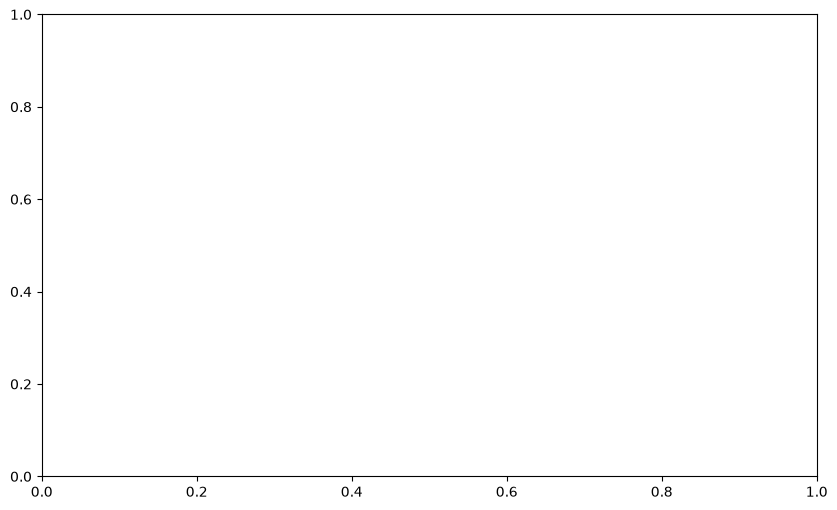

In [ ]:
import matplotlib.pyplot as plt
OUT = ROOT_DIR / 'data' / 'processed' / 'china-quantities-monthly.csv'

# merge both gacc_df and quant_china_df
merged_df = pd.merge(quant_china_df, gacc_df, left_on='TIME_PERIOD', right_on='period', how='outer')
# density factor 7.32 bbl/tonne, qty_10000t * 10 gives thousand tonnes, * 7.32 gives thousand barrels for the month, / days_in_month gives kb/d = crude_kbd
merged_df['days'] = merged_df['TIME_PERIOD'].dt.days_in_month
merged_df['gacc_crude_kbd'] = merged_df['crude_qty_10000t'] * 10 * 7.32 / merged_df['days']
merged_df['discrepancy_crude'] = merged_df['gacc_crude_kbd'] - merged_df['TOTIMPSB']
merged_df.loc[merged_df['discrepancy_crude'].notna(), ['period', 'gacc_crude_kbd', 'TOTIMPSB', 'discrepancy_crude']]
merged_df['cny_affected'] = merged_df['TIME_PERIOD'].dt.month.isin([1,2])

fig, ax = plt.subplots(figsize=(10,6))
merged_df['year'] = merged_df['TIME_PERIOD'].dt.year
merged_df['month'] = merged_df['TIME_PERIOD'].dt.month
merged_df['ratio'] = merged_df['TOTIMPSB'] / merged_df.groupby('year')['TOTIMPSB'].transform('mean')
seasonal = (
    merged_df[merged_df['year'] <= 2025]
    .groupby('month')['ratio']
    .mean()
)
print(seasonal.round(3))
merged_df.sort_values('period').to_csv(OUT, index=False)
